 -*- coding: utf-8 -*-  <br>
 MBA Data Science e Analytics USP/ESALQ <br>
 Código para o desenvolvimento do TCC - Parte 01 <br>
 Autor: Ronaldo do Couto Silva Filho

 # Previsão de preço de Ethereum e Solana um estudo comparativo de técnicas de Machine Learning

 ## Objetivo

 O presente notebook tem como objetivo demonstrar a implementação de um
 algoritmo de machine learnig que possa auxiliar a tomada de decisão na compra
 de criptoativos, por meio da análise de dados históricos: preço, permitindo
 identificar padrões e prever movimentações de mercado.

 Para tal será realizada uma análise comparativa da precisão de previsões dos
 preços das criptomoedas Ether e Sol, utilizando três técnicas distintas de
 aprendizado de máquina: Random Forest [RF], LSTM e GRU. Pretende-se avaliar a
 eficiência e acurácia de cada modelo nas previsões, por meio das métricas de
 Erro Quadrático Médio [MSE], Raiz do Erro Quadrático Médio [RMSE],
 Erro Médio Absoluto Escalado [MASE], proporcionando uma compreensão sobre o
 desempenho de cada abordagem.


 ## Estrutura do Trabalho

 1. Coleta de Dados
 2. Análise Explorativa de Dados
 3. Pré-processamento dos Dados
 4. Aplicação de Técnicas de Machine Learning
 5. Validação e Teste dos Modelos
 6. Interpretação dos Resultados

 ### 1. Coleta de Dados
 Recolher dados históricos de preços de diferentes criptoativos, volume de
 negociação, entre outras variáveis relevantes.

 Os dados utilizados nesse trabalho foram extraidos do notebook presente no
 Kaggle: [The Most 50 Popular Crypto Data](https://www.kaggle.com/datasets/kaanxtr/btc-price-1m?resource=download).


 ### 2. Análise Explorativa de Dados:
 Realizar uma análise inicial dos dados para entender melhor os padrões
 históricos e a correlação entre diferentes criptoativos.
 Utilizar visualizações gráficas e estatísticas descritivas para identificar
 tendências e anomalias.


In [ ]:
# Importação de Pacotes
import os
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from utils import formatar_grafico_mbausp
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

In [ ]:
# Importar base de dados
eth_data = pd.read_csv("../databases_origin/ETHUSDT.csv")
sol_data = pd.read_csv("../databases_origin/SOLUSDT.csv")

In [ ]:
# Visualização das variáveis presentes no dataset
print(eth_data.keys(),sol_data.keys(), sep="\n\n")

Index(['timestamp', 'open', 'high', 'low', 'close', 'volume', 'close_time',
       'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume',
       'taker_buy_quote_asset_volume', 'ignore'],
      dtype='object')

Index(['timestamp', 'open', 'high', 'low', 'close', 'volume', 'close_time',
       'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume',
       'taker_buy_quote_asset_volume', 'ignore'],
      dtype='object')


In [ ]:
# Visualização das 6 primeiras observações
eth_data.head()

,timestamp,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,ignore
0,2017-08-17 04:00:00,301.13,301.13,301.13,301.13,0.42643,2017-08-17 04:00:59.999,128.410866,2,0.42643,128.410866,0
1,2017-08-17 04:01:00,301.13,301.13,301.13,301.13,2.75787,2017-08-17 04:01:59.999,830.477393,4,2.75787,830.477393,0
2,2017-08-17 04:02:00,300.00,300.00,300.00,300.00,0.09930,2017-08-17 04:02:59.999,29.790000,2,0.09930,29.790000,0
3,2017-08-17 04:03:00,300.00,300.00,300.00,300.00,0.31389,2017-08-17 04:03:59.999,94.167000,3,0.00000,0.000000,0
4,2017-08-17 04:04:00,301.13,301.13,301.13,301.13,0.23202,2017-08-17 04:04:59.999,69.868183,1,0.23202,69.868183,0


In [ ]:
# Visualização das estatisticas associadas em cada dataset
sol_data.describe() 

,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,ignore
count,2.282218e+06,2.282218e+06,2.282218e+06,2.282218e+06,2.282218e+06,2.282218e+06,2.282218e+06,2.282218e+06,2.282218e+06,2282218.0
mean,7.235783e+01,7.242757e+01,7.228716e+01,7.235793e+01,3.141317e+03,2.238891e+05,3.872152e+02,1.562701e+03,1.119711e+05,0.0
std,6.679234e+01,6.685188e+01,6.673161e+01,6.679240e+01,6.147082e+03,4.981516e+05,8.148260e+02,3.330623e+03,2.667243e+05,0.0
min,1.079400e+00,1.101500e+00,1.030100e+00,1.059200e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,2.055000e+01,2.056000e+01,2.054000e+01,2.055000e+01,6.364800e+02,1.844467e+04,4.900000e+01,2.500600e+02,7.432993e+03,0.0
50%,3.798000e+01,3.803600e+01,3.792800e+01,3.798000e+01,1.476420e+03,7.625034e+04,1.470000e+02,6.747065e+02,3.480871e+04,0.0
75%,1.346600e+02,1.347700e+02,1.345500e+02,1.346600e+02,3.338210e+03,2.304829e+05,3.920000e+02,1.635057e+03,1.110347e+05,0.0
max,2.641900e+02,2.643900e+02,2.634700e+02,2.641900e+02,6.430630e+05,5.914110e+07,6.262500e+04,3.472126e+05,4.120742e+07,0.0


In [ ]:
# Selecionar a Cripto a ser analisada
cripto_lista = {"eth":eth_data, "sol":sol_data}

 Nesse momento do código é definido qual a criptomoeda a ser utilizada para
 criar as bases de dados necessárias. O código foi escrito utilizando como
 referência solana, cujo nome está sendo referido no dicionário cripto_lista,
 como **"sol"**. O presente código se aplica a demais criptomoedas, no entanto,
 para utilizá-lo é necessário importar os dados seguindo a estrutura acima. <br>

 **Procedimento**:  <br>
 Salve a base de dados a ser utilizada na pasta databases, no formato .csv <br>
 OBS: Se o seu dataset estiver em outro formato adapte o código tanto quanto
 necessário.  <br>

 Rode o código abaixo adaptando o NomeDaCriptomoeda pela referida cripto,
 como por exemplo BTC <br>

 `NomeDaCriptomoeda_data = pd.read_csv("databases/NomeDaCriptomoedaUSDT.csv")
 cripto_lista = {"NomeDaCriptomoeda": NomeDaCriptomoeda_data}`

In [ ]:
# Selecionar a Criptomoeda e as variáveis que serão analisadas
cripto_name = "eth"

cripto = cripto_lista[cripto_name][['timestamp', 'close']]

cripto['timestamp'] = pd.to_datetime(cripto['timestamp'])

cripto.set_index('timestamp', inplace=True)

<ipython-input-7-7c2b3bb0b56d>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cripto['timestamp'] = pd.to_datetime(cripto['timestamp'])


In [ ]:
# Procurar por valores nulos:
null_values = cripto.isna().sum()
print(null_values)

close    0
dtype: int64


In [ ]:
# Criação de Objeto TimeSeries (mais leve e rápido)
cripto_ts = pd.Series(data=cripto['close'].values,index=cripto.index)

print(cripto_ts.head())  # Verifique os primeiros valores

cripto_ts.describe()

timestamp
2017-08-17 04:00:00    301.13
2017-08-17 04:01:00    301.13
2017-08-17 04:02:00    300.00
2017-08-17 04:03:00    300.00
2017-08-17 04:04:00    301.13
dtype: float64


count    3.844750e+06
mean     1.440185e+03
std      1.217077e+03
min      8.203000e+01
25%      2.718700e+02
50%      1.279300e+03
75%      2.333800e+03
max      4.865220e+03
dtype: float64

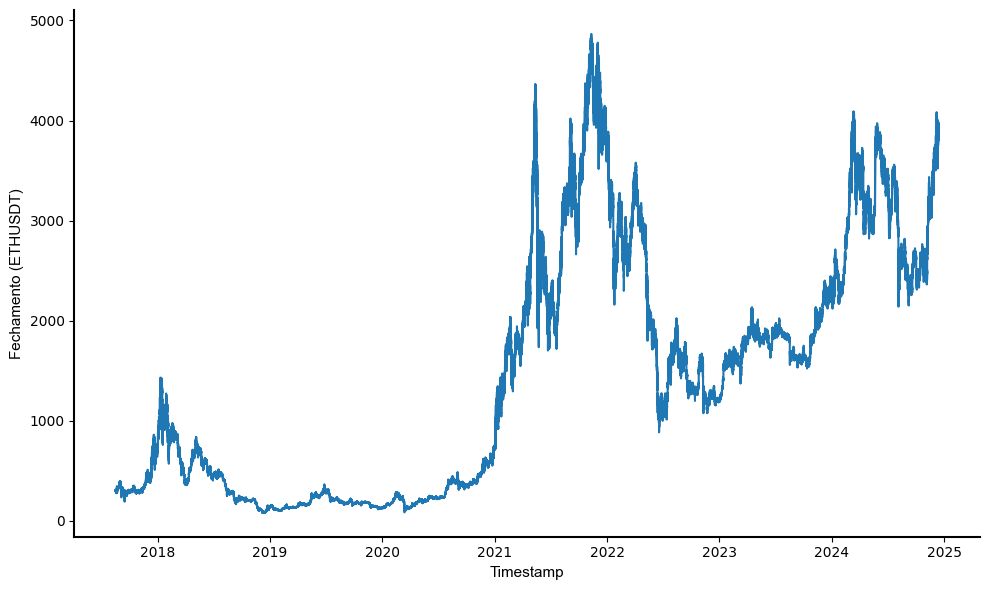

In [ ]:
titulo_y = f'Fechamento ({cripto_name.upper()}USDT)'
# Grafico da série temporal
formatar_grafico_mbausp((cripto_ts.index, cripto_ts),
                        titulo_x="Timestamp",
                        titulo_y=titulo_y)

 > Com o objetivo de estudar intervalos mais espaçados de dados, foram criados
 resamples com intervalos de 30 a 30 minutos, hora em hora e dia a dia.

In [ ]:
# Realizando o resamplying dos dados

# 30 min
cripto_30min = cripto.resample('30T').mean()
print(cripto_30min)

# 1 hora
cripto_1hr = cripto.resample('1H').mean()
print(cripto_1hr)

# 1 dia
cripto_1dia = cripto.resample('1D').mean()
print(cripto_1dia)

<ipython-input-11-6453237610de>:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  cripto_30min = cripto.resample('30T').mean()


                           close
timestamp                       
2017-08-17 04:00:00   299.319667
2017-08-17 04:30:00   300.374333
2017-08-17 05:00:00   302.151000
2017-08-17 05:30:00   302.791000
2017-08-17 06:00:00   302.762667
...                          ...
2024-12-14 01:00:00  3927.454333
2024-12-14 01:30:00  3930.985333
2024-12-14 02:00:00  3912.603333
2024-12-14 02:30:00  3911.997667
2024-12-14 03:00:00  3911.630000

[128447 rows x 1 columns]
                           close
timestamp                       
2017-08-17 04:00:00   299.847000
2017-08-17 05:00:00   302.471000
2017-08-17 06:00:00   303.031500
2017-08-17 07:00:00   304.488167
2017-08-17 08:00:00   309.176167
...                          ...
2024-12-13 23:00:00  3903.888167
2024-12-14 00:00:00  3913.637333
2024-12-14 01:00:00  3929.219833
2024-12-14 02:00:00  3912.300500
2024-12-14 03:00:00  3911.630000

[64224 rows x 1 columns]
                  close
timestamp              
2017-08-17   306.863258
2017-08-18   300.

<ipython-input-11-6453237610de>:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  cripto_1hr = cripto.resample('1H').mean()



 > Com o resample dos dados é possível que tenham sido criados intervalos com
 valores nulos, e para corrigir tal equívoco (devido a falta de dados) como a
 cotação/preço de um ativo é o último valor por ele, os valores nulos foram
 preenchidos usando o método forwardfill.

In [ ]:
# Lista de resamples
resample_cripto = [cripto, cripto_30min, cripto_1hr, cripto_1dia]

for df in resample_cripto:
    # Preenchendo os valores de fechamento com o método de forwarfill
    df["close"] = df["close"].fillna(method='ffill')

<ipython-input-12-f5ec325afddd>:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["close"] = df["close"].fillna(method='ffill')
<ipython-input-12-f5ec325afddd>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["close"] = df["close"].fillna(method='ffill')


In [ ]:
# Decomposição de Séries Temporais

# Decomposicao pelo modelo ADITIVO
cripto_decomp_add = seasonal_decompose(cripto["close"], model='aditive',
                                    period=60*24*30*12)

# Decomposicao pelo modelo MULTIPLICATIVO
cripto_decomp_mult = seasonal_decompose(cripto["close"], model='multiplicative',
                                    period=60*24*30*12)

In [ ]:
# Analisar o resíduo para selecionar o melhor modelo
# Modelo Aditivo
reconstruida_add = cripto_decomp_add.trend + cripto_decomp_add.seasonal

# Modelo Multiplicativo
reconstruida_mult = cripto_decomp_mult.trend + cripto_decomp_mult.seasonal

# Remover NaNs causados pela decomposição
# Modelo Aditivo
validos_add = reconstruida_add.dropna()
original = cripto["close"].loc[validos_add.index]

# Modelo Multiplicativo
validos_mult = reconstruida_mult.dropna()
original = cripto["close"].loc[validos_mult.index]

# Calculo do RMSE
rmse_add = mean_squared_error(original, validos_add)
rmse_mult = mean_squared_error(original, validos_mult)

print(f'RMSE do modelo ADITIVO: {rmse_add:.2f}')
print(f'RMSE do modelo MULTIPLICATIVO: {rmse_mult:.2f}')

RMSE do modelo ADITIVO: 126594.60
RMSE do modelo MULTIPLICATIVO: 148013.33



 > Ambos os modelos apresentam um alto RMSE, não representando
 significativamente a série temporal. O modelo ADITIVO, no entanto, apresenta
 melhor resultado.

Modelo Aditivo:


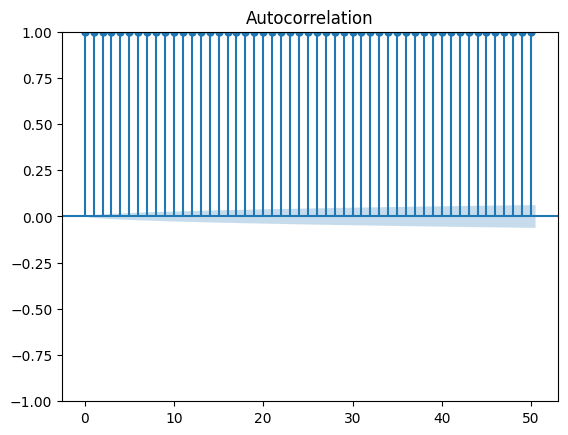

In [ ]:
# Avaliação do resíduos do modelo aditivo
residuos_add = cripto_decomp_add.resid.dropna()

print("Modelo Aditivo:")

plot_acf(residuos_add.tail(100_000), lags=50)
plt.show()

Modelo Multiplicativo:


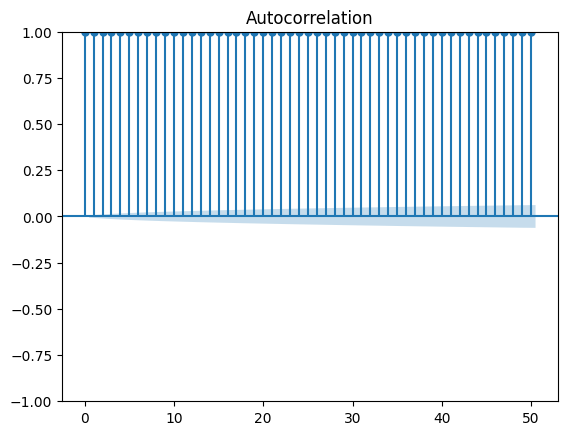

In [ ]:
# Avaliação do resíduos do modelo multiplicativo
residuos_mult = cripto_decomp_mult.resid.dropna()

print("Modelo Multiplicativo:")

plot_acf(residuos_mult.tail(100_000), lags=50)
plt.show()

 > Por restrições computacionais foi optado por plotar a curva da função de
 autocorrelação com o método `plot_acf`. É possível observar a alta correlação
 dos pontos residuais. Dessa forma, é evidente que a decomposição sazonal, por
 si só não é um bom modelo ajustado a cotações de criptoativos, e para tal, em
 seguida usaremos técnicas mais sofisticadas para modelar seu comportamento.

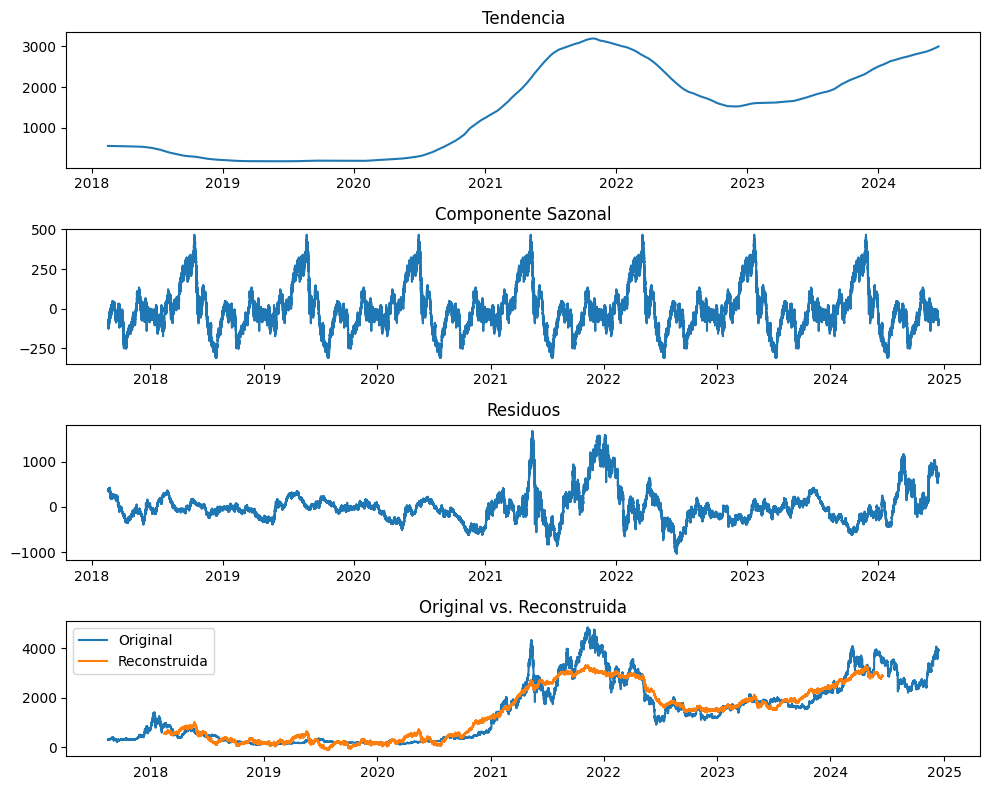

In [ ]:
# Plotar decomposição aditiva da série temporal
# Reconstrução da série (sem o resíduo)
plt.figure(figsize=(10, 8))
plt.subplot(4, 1, 1)
plt.plot(cripto_decomp_add.trend)
plt.title('Tendencia')

plt.subplot(4, 1, 2)
plt.plot(cripto_decomp_add.seasonal)
plt.title('Componente Sazonal')

plt.subplot(4, 1, 3)
plt.plot(cripto_decomp_add.resid)
plt.title('Residuos')

plt.subplot(4, 1, 4)
plt.plot(cripto_1hr["close"], label='Original')
plt.plot(cripto_decomp_add.trend + cripto_decomp_add.seasonal, 
         label='Reconstruida')

plt.title('Original vs. Reconstruida')
plt.legend()

plt.tight_layout()
plt.show()

 ### 3. Pré-processamento dos Dados

 Criar features e processar os dados necessários para dar início ao processo de
 análise dos dados

In [ ]:
# Criação de Feature adicionais
# Random Forest não lida diretamente com a dependência temporal, como outros 
# modelos # especializados em séries temporais (ARIMA, LSTM). Para contornar 
# isso, é necessário criar variáveis explicativas (X) a partir de transformações
#  nos dados, como janelas deslizantes, indicadores técnicos ou agregados 
# temporais.

for df in resample_cripto:

    # Retornos percentuais (% variação do preço).
    df['return_pct'] = df['close'].pct_change() * 100

    # Médias móveis (curta e longa duração).

    # Média móvel simples (janela de 10 períodos)
    df['SMA_10'] = df['close'].rolling(window=10).mean()  
    
    # Média móvel exponencial (janela de 10 períodos)
    df['EMA_10'] = df['close'].ewm(span=10, adjust=False).mean()  

    # Índice de Força Relativa (RSI - Relative Strength Index)
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()  #Ganhos médios
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean() #Perdas médias
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    df.dropna(inplace=True)

<ipython-input-18-74a009e4ab77>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['return_pct'] = df['close'].pct_change() * 100
<ipython-input-18-74a009e4ab77>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SMA_10'] = df['close'].rolling(window=10).mean()
<ipython-input-18-74a009e4ab77>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

In [ ]:
# Código para Criação das Bases de Dados, a ser alterado para cada criptomoeda
os.makedirs("../databases_parquet", exist_ok=True)

if cripto_name == "sol":
    cripto_30min.to_parquet("../databases_parquet/sol_30min")
    cripto_1hr.to_parquet("../databases_parquet/sol_1hr")
    cripto_1dia.to_parquet("../databases_parquet/sol_1dia")
    cripto.to_parquet("../databases_parquet/sol_1min")

elif cripto_name == "eth":
    cripto_30min.to_parquet("../databases_parquet/eth_30min")
    cripto_1hr.to_parquet("../databases_parquet/eth_1hr")
    cripto_1dia.to_parquet("../databases_parquet/eth_1dia")
    cripto.to_parquet("../databases_parquet/eth_1min")